## 📌 Extracción

In [33]:
!cp "/content/drive/MyDrive/Colab Notebooks/TelecomX.ipynb"    /content/Challenge_TelecomX/

In [34]:
%%bash
cd /content/Challenge_TelecomX
git add .
git commit -m "Final"
git push origin main   # o 'master' si tu repo usa master

[main f1141e6] Final
 1 file changed, 1 insertion(+)
 create mode 100644 TelecomX.ipynb


To https://github.com/JadsielT/Challenge_TelecomX.git
   fdda41d..f1141e6  main -> main


In [ ]:
import requests
import json
import pandas as pd
datos_API = requests.get('https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json')
resultado = json.loads(datos_API.text)
pd.DataFrame(resultado)

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


# 🔧 Transformación

In [ ]:
df = pd.json_normalize(resultado)
df.head()


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:
new_columns = []
for col in df.columns:
    if col.startswith('customer.'):
        new_columns.append(col.replace('customer.', ''))
    elif col.startswith('phone.'):
        new_columns.append(col.replace('phone.', ''))
    elif col.startswith('internet.'):
        new_columns.append(col.replace('internet.', ''))
    elif col.startswith('account.'):
        new_columns.append(col.replace('account.', ''))
    else:
        new_columns.append(col)
df.columns = new_columns
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:

for column in  df.columns[1:]:
    unique_values = df[column].sort_values().unique()
    if len(unique_values) < 10:
        print(column, '\n',unique_values, '\n')
    else:
        print(column, '\nMin:',min(unique_values), '\t Max:', max(unique_values), '\n')


Churn 
 ['' 'No' 'Yes'] 

gender 
 ['Female' 'Male'] 

SeniorCitizen 
 [0 1] 

Partner 
 ['No' 'Yes'] 

Dependents 
 ['No' 'Yes'] 

tenure 
Min: 0 	 Max: 72 

PhoneService 
 ['No' 'Yes'] 

MultipleLines 
 ['No' 'No phone service' 'Yes'] 

InternetService 
 ['DSL' 'Fiber optic' 'No'] 

OnlineSecurity 
 ['No' 'No internet service' 'Yes'] 

OnlineBackup 
 ['No' 'No internet service' 'Yes'] 

DeviceProtection 
 ['No' 'No internet service' 'Yes'] 

TechSupport 
 ['No' 'No internet service' 'Yes'] 

StreamingTV 
 ['No' 'No internet service' 'Yes'] 

StreamingMovies 
 ['No' 'No internet service' 'Yes'] 

Contract 
 ['Month-to-month' 'One year' 'Two year'] 

PaperlessBilling 
 ['No' 'Yes'] 

PaymentMethod 
 ['Bank transfer (automatic)' 'Credit card (automatic)' 'Electronic check'
 'Mailed check'] 

Charges.Monthly 
Min: 18.25 	 Max: 118.75 

Charges.Total 
Min:   	 Max: 999.9 



In [ ]:
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


### Eliminación de filas con valores vacíos (regenerado)

Regenerando el código para limpiar los valores de cadena vacía (' ') en el DataFrame. Se reemplazarán por `NaN` y se eliminarán las filas afectadas.

In [ ]:
import numpy as np

print(f"Filas antes de la eliminación: {len(df)}")

# Para la columna 'Churn'
df['Churn'] = df['Churn'].replace('', np.nan)

# Para la columna 'Charges.Total', que es tipo objeto y debería ser numérica
# Primero, se fuerza la conversión a numérico, convirtiendo errores a NaN, y luego se reemplaza ' ' por NaN
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

# Se eliminan las filas donde 'Churn' o 'Charges.Total' sean NaN
df.dropna(subset=['Churn', 'Charges.Total'], inplace=True)

print(f"Filas después de la eliminación: {len(df)}")

# Mostrar las primeras filas del DataFrame limpio
display(df.head())

Filas antes de la eliminación: 7267
Filas después de la eliminación: 7032


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [ ]:
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [ ]:
for column in  df.columns[1:]:
    unique_values = df[column].sort_values().unique()
    if len(unique_values) < 10:
        print(column, '\n',unique_values, '\n')
    else:
        print(column, '\nMin:',min(unique_values), '\t Max:', max(unique_values), '\n')


Churn 
 ['No' 'Yes'] 

gender 
 ['Female' 'Male'] 

SeniorCitizen 
 [0 1] 

Partner 
 ['No' 'Yes'] 

Dependents 
 ['No' 'Yes'] 

tenure 
Min: 1 	 Max: 72 

PhoneService 
 ['No' 'Yes'] 

MultipleLines 
 ['No' 'No phone service' 'Yes'] 

InternetService 
 ['DSL' 'Fiber optic' 'No'] 

OnlineSecurity 
 ['No' 'No internet service' 'Yes'] 

OnlineBackup 
 ['No' 'No internet service' 'Yes'] 

DeviceProtection 
 ['No' 'No internet service' 'Yes'] 

TechSupport 
 ['No' 'No internet service' 'Yes'] 

StreamingTV 
 ['No' 'No internet service' 'Yes'] 

StreamingMovies 
 ['No' 'No internet service' 'Yes'] 

Contract 
 ['Month-to-month' 'One year' 'Two year'] 

PaperlessBilling 
 ['No' 'Yes'] 

PaymentMethod 
 ['Bank transfer (automatic)' 'Credit card (automatic)' 'Electronic check'
 'Mailed check'] 

Charges.Monthly 
Min: 18.25 	 Max: 118.75 

Charges.Total 
Min: 18.8 	 Max: 8684.8 



Columna cuentas diarias

In [ ]:
df['cuentas_diarias'] = df['Charges.Monthly'] / 30
df

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,cuentas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


In [ ]:
import numpy as np

binarias = [
    'Churn',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'PaperlessBilling'
]

# 'otras' variable is not used in the original code, so it's kept as is if not needed elsewhere.

for col in binarias:
    # Use np.where for a more explicit and robust mapping
    if col == 'MultipleLines':
        # Replace 'No phone service' with 0, 'Yes' with 1, anything else (like 'No') with 0
        df[col] = np.where(df[col] == 'Yes', 1, np.where(df[col] == 'No phone service', 0, 0))
    elif col in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']:
        # Replace 'No internet service' with 0, 'Yes' with 1, anything else (like 'No') with 0
        df[col] = np.where(df[col] == 'Yes', 1, np.where(df[col] == 'No internet service', 0, 0))
    else:
        # For other binary columns like 'Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling'
        # Assuming these only contain 'Yes' or 'No', map 'Yes' to 1 and 'No' to 0.
        df[col] = np.where(df[col] == 'Yes', 1, 0)

df.to_csv('DF_TRATADO.csv', index=False)

In [ ]:
df.isna().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


# 📊 Carga y análisis

Análisis Descriptivo

In [ ]:
# Estadísticas descriptivas con formato claro
desc = df.describe()

# Convertir a object para evitar warnings
formatted = desc.astype(object)

# Columnas binarias
binarias = [
    'Churn','SeniorCitizen','Partner','Dependents',
    'PhoneService','MultipleLines','OnlineSecurity',
    'OnlineBackup','DeviceProtection','TechSupport',
    'StreamingTV','StreamingMovies','PaperlessBilling'
]

for col in binarias:
    for idx in formatted.index:
        if idx == 'count':
            formatted.loc[idx, col] = f"{int(desc.loc[idx, col])}"
        else:
            formatted.loc[idx, col] = f"{desc.loc[idx, col]*100:.2f}%"

# Columnas monetarias
monetarias = ['Charges.Monthly','Charges.Total','cuentas_diarias']
for col in monetarias:
    for idx in formatted.index:
        if idx == 'count':
            formatted.loc[idx, col] = f"{int(desc.loc[idx, col])}"
        else:
            formatted.loc[idx, col] = f"${desc.loc[idx, col]:,.2f}"

# Tenure
col = 'tenure'
for idx in formatted.index:
    if idx == 'count':
        formatted.loc[idx, col] = f"{int(desc.loc[idx, col])}"
    else:
        formatted.loc[idx, col] = f"{desc.loc[idx, col]:.2f}"

# Mostrar tabla
display(formatted)

# Notas interpretativas automáticas
print("\nNotas interpretativas:")
print(f"- Churn: {desc.loc['mean','Churn']*100:.2f}% de clientes se dieron de baja.")
print(f"- SeniorCitizen: {desc.loc['mean','SeniorCitizen']*100:.2f}% son adultos mayores.")
print(f"- Partner: {desc.loc['mean','Partner']*100:.2f}% tienen pareja.")
print(f"- Dependents: {desc.loc['mean','Dependents']*100:.2f}% tienen dependientes.")
print(f"- Tenure: mediana = {desc.loc['50%','tenure']:.0f} meses, máximo = {desc.loc['max','tenure']:.0f} meses.")
print(f"- cargos mensuales: media = ${desc.loc['mean','Charges.Monthly']:.2f}, mediana = ${desc.loc['50%','Charges.Monthly']:.2f}.")
print(f"- cargos totales: media = ${desc.loc['mean','Charges.Total']:.2f}, mediana = ${desc.loc['50%','Charges.Total']:.2f}, máximo = ${desc.loc['max','Charges.Total']:.2f}.")
print(f"- cuentas diarias: media = ${desc.loc['mean','cuentas_diarias']:.2f}, mediana = ${desc.loc['50%','cuentas_diarias']:.2f}.")


,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Charges.Monthly,Charges.Total,cuentas_diarias
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
mean,26.58%,16.24%,48.25%,29.85%,32.42,90.33%,42.19%,28.65%,34.49%,34.39%,29.01%,38.44%,38.84%,59.27%,$64.80,"$2,283.30",$2.16
std,44.18%,36.88%,49.97%,45.76%,24.55,29.56%,49.39%,45.22%,47.54%,47.50%,45.38%,48.65%,48.74%,49.14%,$30.09,"$2,266.77",$1.00
min,0.00%,0.00%,0.00%,0.00%,1.00,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,$18.25,$18.80,$0.61
25%,0.00%,0.00%,0.00%,0.00%,9.00,100.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,$35.59,$401.45,$1.19
50%,0.00%,0.00%,0.00%,0.00%,29.00,100.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,100.00%,$70.35,"$1,397.47",$2.34
75%,100.00%,0.00%,100.00%,100.00%,55.00,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,$89.86,"$3,794.74",$3.00
max,100.00%,100.00%,100.00%,100.00%,72.00,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,$118.75,"$8,684.80",$3.96



Notas interpretativas:
- Churn: 26.58% de clientes se dieron de baja.
- SeniorCitizen: 16.24% son adultos mayores.
- Partner: 48.25% tienen pareja.
- Dependents: 29.85% tienen dependientes.
- Tenure: mediana = 29 meses, máximo = 72 meses.
- cargos mensuales: media = $64.80, mediana = $70.35.
- cargos totales: media = $2283.30, mediana = $1397.47, máximo = $8684.80.
- cuentas diarias: media = $2.16, mediana = $2.34.


Distribución de evasión

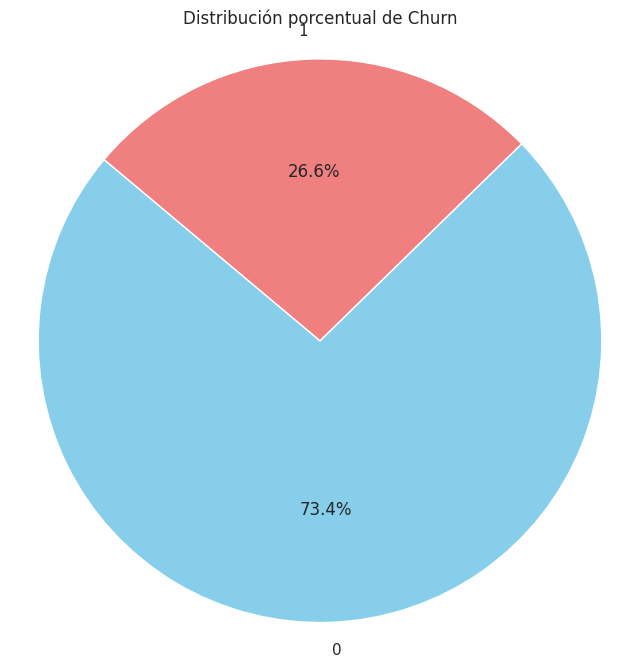

In [ ]:
import matplotlib.pyplot as plt

churn_counts = df['Churn'].value_counts()
churn_percentages = churn_counts / len(df) * 100

plt.figure(figsize=(8, 8))
plt.pie(churn_percentages, labels=churn_percentages.index, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'lightcoral'])
plt.title('Distribución porcentual de Churn')
plt.axis('equal')
plt.show()

Recuento de evasión por variables categóricas

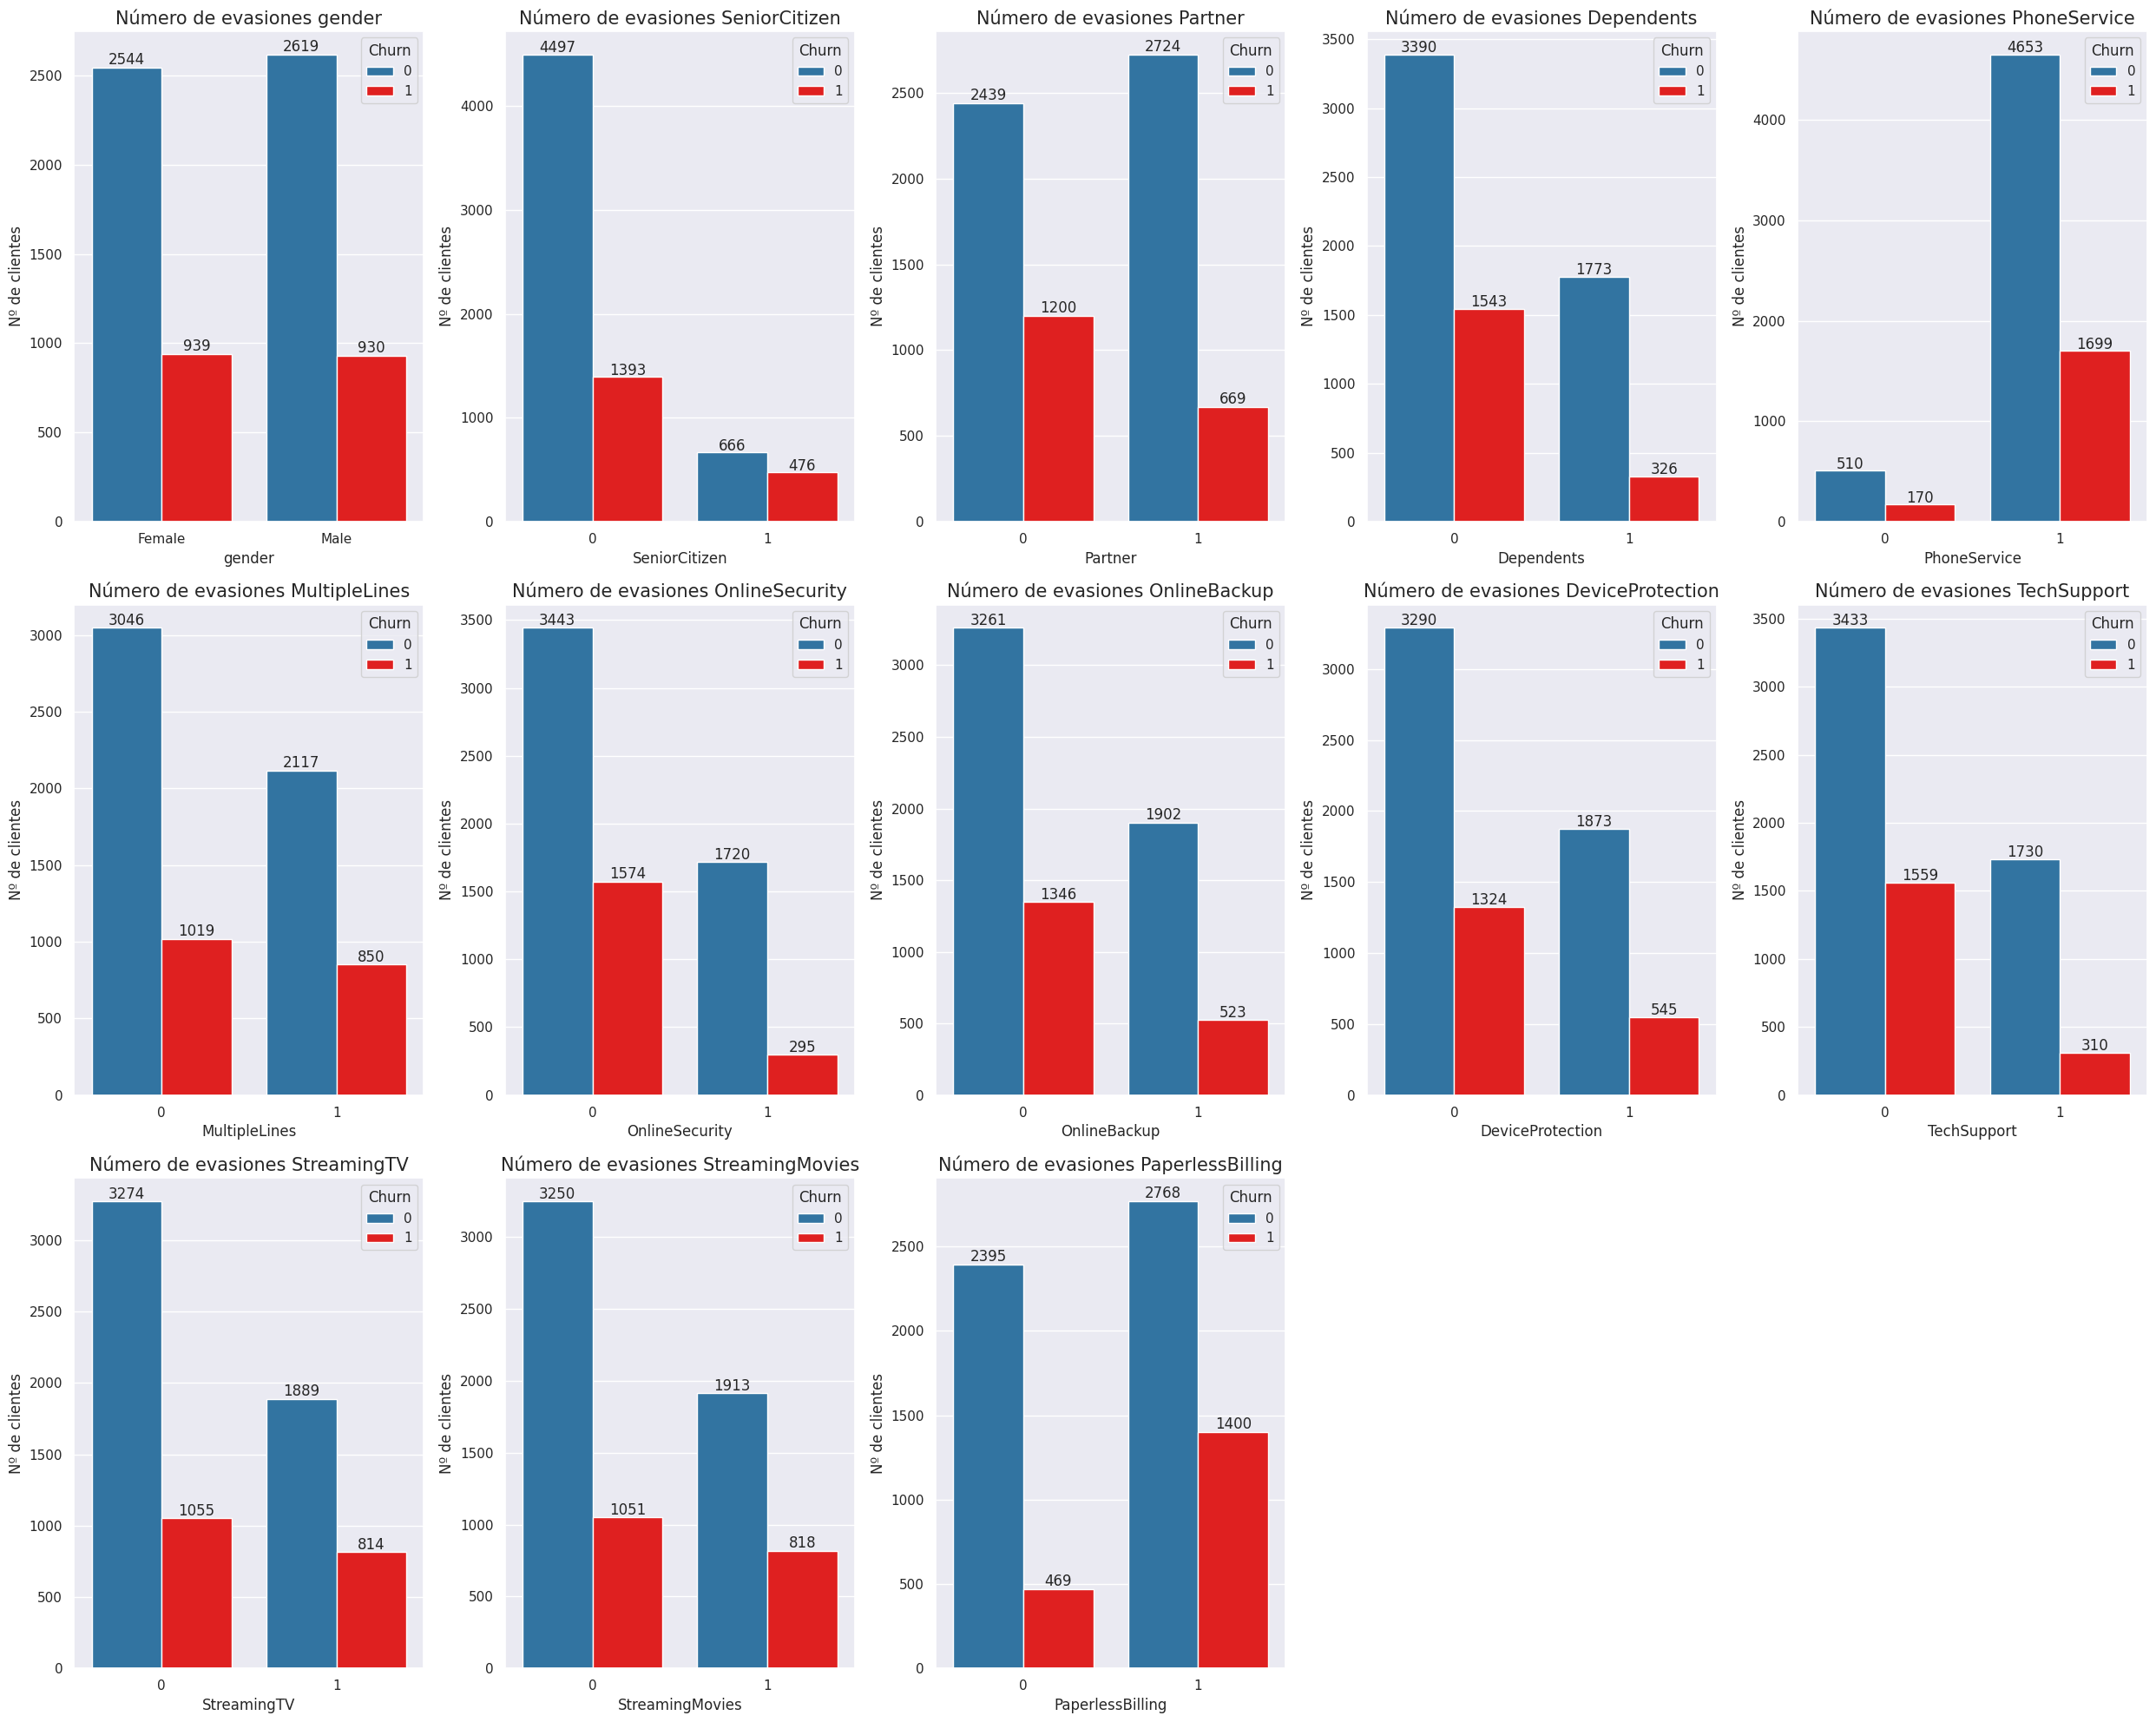

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

variables_categoricas = ['gender','SeniorCitizen', 'Partner', 'Dependents',
                         'PhoneService', 'MultipleLines', 'OnlineSecurity',
                         'OnlineBackup', 'DeviceProtection', 'TechSupport',
                         'StreamingTV', 'StreamingMovies', 'PaperlessBilling']

lista_variables_categoricas = list(enumerate(variables_categoricas))

sns.set(rc = {'figure.figsize':(25,20)})

for i in lista_variables_categoricas:

    plt.subplot(3, 5,  i[0]+1)
    ax = sns.countplot(data = df,
                    x = i[1],
                    hue = 'Churn',
                    palette = {0: '#1f77b4', 1: 'red'},
                    )

    ax.set_title(f'Número de evasiones {i[1]}', fontsize = 15) #Agregar un título y aumentar el tamaño de fuente.
    ax.set_ylabel('Nº de clientes', fontsize = 12) #Cambiar el título del eje Y y aumentar el tamaño de la fuente.
    ax.set_xlabel(i[1], fontsize = 12) #Cambiar el título del eje X y aumentar el tamaño de la fuente.

    #Cambiar rotación en el eje X sólo para la gráfica de metodo_pago
    if i[1] == '	PaymentMethod':
        plt.xticks(rotation=45, ha='right')

    #Agregar etiqueta de datos para el Nº de clientes.
    for p in ax.patches:
        height = p.get_height()
        #Se agrega validación para no imprimir etiquetas en valores nulos o cero
        if height > 0:
            ax.text(p.get_x()+p.get_width()/2.,
            height + 20,
            '{:1.0f}'.format(height),#Se ajusta el formato para evitar decimales innecesarios
            ha='center',
            size = 12)

plt.tight_layout() #Ajustar el espacio entre gráficas
plt.show()

Gender: La evasión es muy similar entre hombres y mujeres, sin diferencias significativas.

SeniorCitizen: Los clientes que no son adultos mayores presentan mayor número total de evasiones que los adultos mayores.

Partner: Los clientes sin pareja tienden a evadir más que aquellos con pareja.

Dependents: Los clientes sin dependientes muestran mayor evasión que quienes sí tienen dependientes.

PhoneService: La mayoría de las evasiones se da en clientes que cuentan con servicio telefónico.

----------------------------------------------------------------------------------------------------

MultipleLines: La evasión es similar entre quienes tienen y no tienen múltiples líneas.

OnlineSecurity: Los clientes sin seguridad en línea presentan mucha mayor evasión que quienes sí la tienen.

OnlineBackup: La evasión es considerablemente mayor en clientes sin respaldo en línea.

DeviceProtection: Los clientes sin protección de dispositivo tienden a evadir más que quienes cuentan con este servicio.

TechSupport: La mayor evasión se concentra en clientes que no tienen soporte técnico.

-------------------------------------------------------------------------------------------------------
StreamingTV: La evasión es ligeramente mayor en clientes que no tienen StreamingTV que en los que sí lo tienen.

StreamingMovies: Los clientes sin StreamingMovies presentan un poco más de evasión que quienes cuentan con el servicio.

PaperlessBilling: La evasión es considerablemente mayor en clientes que usan facturación electrónica (PaperlessBilling).

Conteo de evasión por variables numéricas

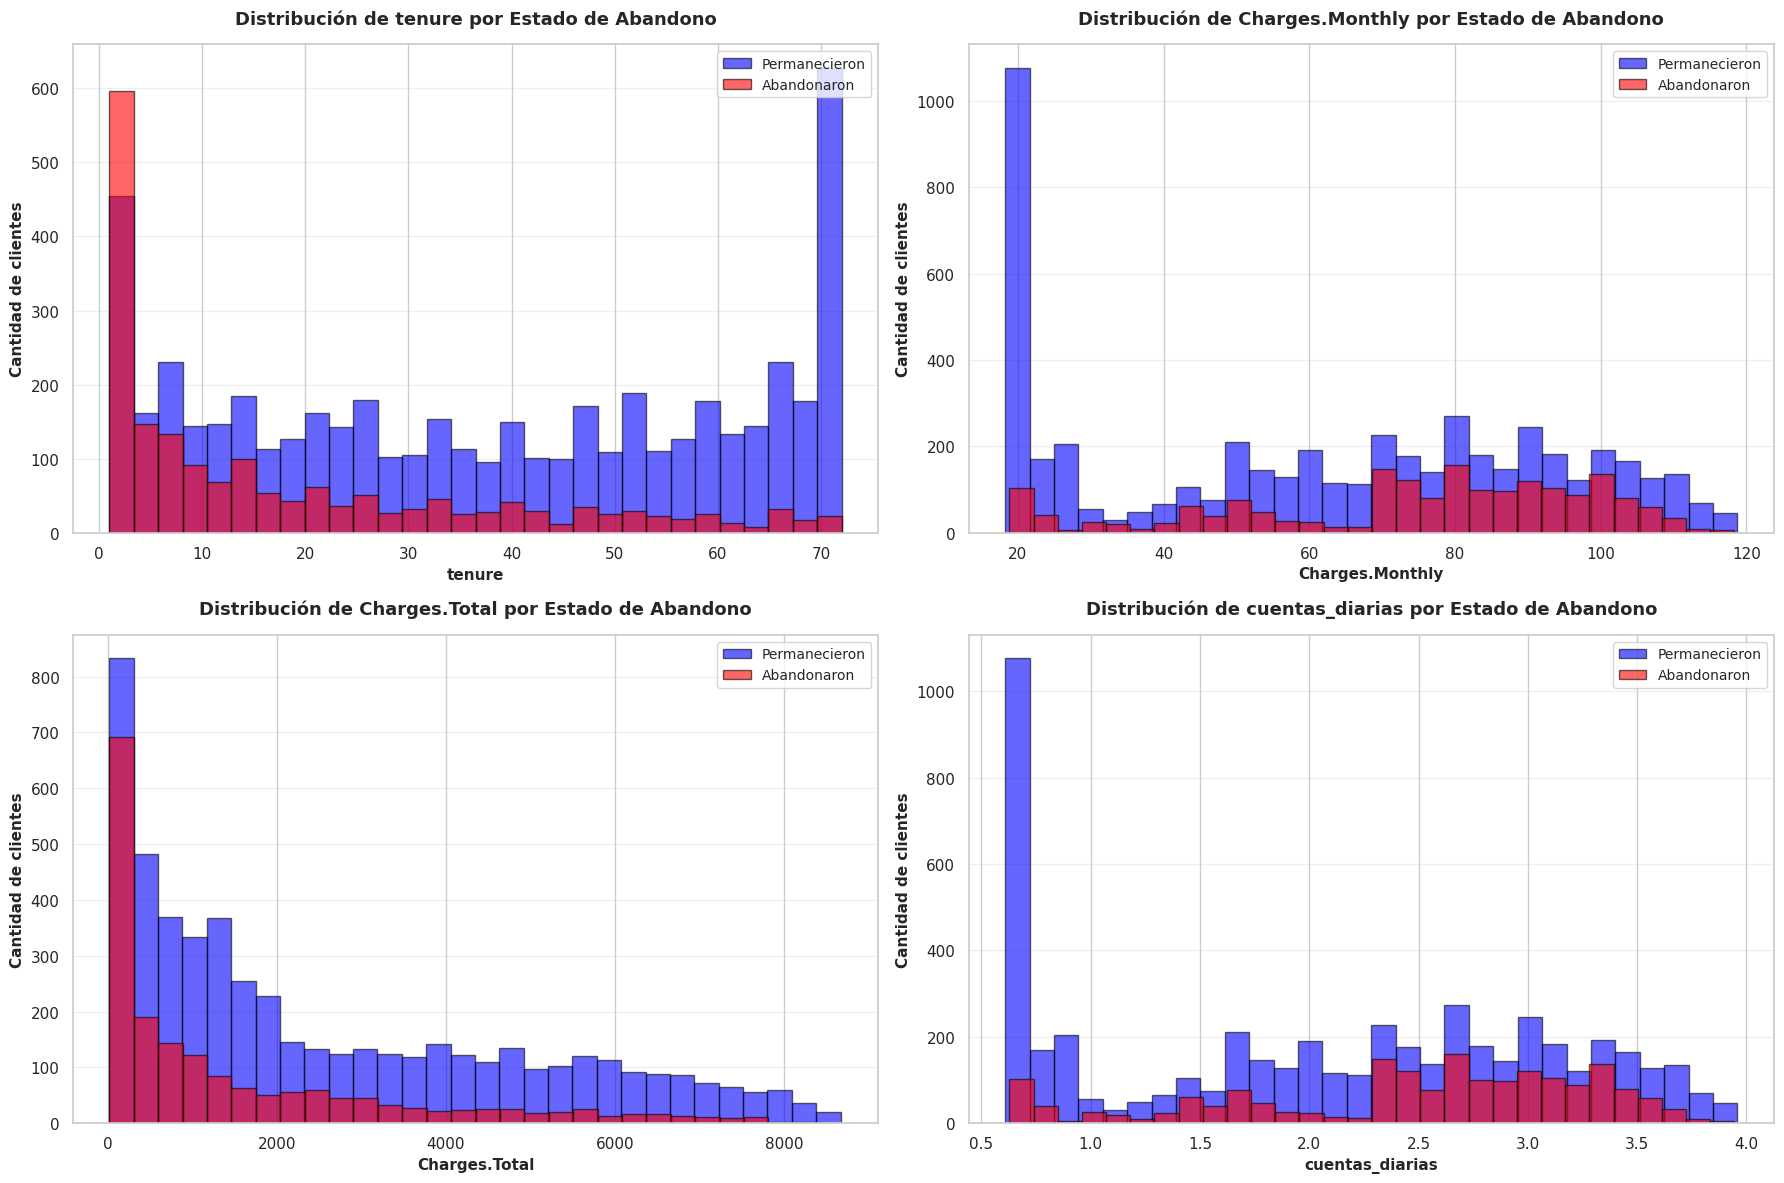

In [ ]:
# Seleccionar variables numéricas relevantes
variables_numericas = ['tenure', 'Charges.Monthly', 'Charges.Total', 'cuentas_diarias']

# Configurar estilo
sns.set_style("whitegrid")
colores_churn = ['BLUE', 'RED']

# 1. Histogramas con distribución por estado de abandono
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, variable in enumerate(variables_numericas):
    for abandono, color, label in zip([0, 1], colores_churn, ['Permanecieron', 'Abandonaron']):
        datos = df[df['Churn'] == abandono][variable]
        axes[idx].hist(datos, bins=30, alpha=0.6, color=color, label=label, edgecolor='black')

    axes[idx].set_title(f'Distribución de {variable} por Estado de Abandono',
                       fontsize=13, weight='bold', pad=15)
    axes[idx].set_xlabel(variable, fontsize=11, weight='bold')
    axes[idx].set_ylabel('Cantidad de clientes', fontsize=11, weight='bold')
    axes[idx].legend(loc='upper right', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Antiguedad por Churn:**

riesgo de abandono al principio (0 - 5 meses):
La gran mayoría de los clientes que abandonan la empresa lo hacen en sus primeros meses. Es la etapa más crítica.

Estabilización a mediano plazo (10 - 65 meses):
Esto indica que si un cliente supera los primeros meses de prueba, la probabilidad de que se quede aumenta considerablemente.

Fuerte lealtad a largo plazo (Tenure 70 - 72):
Son sumamente leales y la tasa de abandono en este grupo es casi nula.

**Cargo Mensual por Churn:**

Fuerte retención en los planes más baratos (Tarifa ~20):
Hay un pico gigante de color azul en el extremo izquierdo (los que pagan unos $20 al mes). Hay más de 1000 clientes en este grupo y la barra roja (los que abandonan) es diminuta en comparación. Esto significa que los clientes con los planes más económicos son extremadamente leales y rara vez cancelan.

Alto índice de abandono en planes costosos (Tarifas 70 - 110):
En el bloque central y derecho de la gráfica (entre 70 y $110), se observa que las barras rojas son mucho más altas, no solo en cantidad pura, sino en proporción al color azul. En algunas barras (como alrededor de los  80 o  100), casi la mitad de los clientes en ese rango de precio están abandonando el servicio.

Los planes intermedios (Tarifas 30 - 60):
Hay menos volumen de clientes en general en este rango de precios, y aunque hay cancelaciones (rojo), no son tan drásticas como en los planes más caros.


La empresa tiene una crisis de valor en sus servicios Premium. Los clientes que pagan más (entre 70 y 110) son los que más están huyendo. Por el contrario, el servicio básico/económico (20) es un éxito rotundo en términos de retención. Esto sugiere fuertemente que los clientes de planes caros sienten que no están recibiendo suficiente valor por lo que pagan

**Cargo Total por Churn:**

Esta gráfica confirma que el principal problema de rentabilidad de la empresa está en la retención temprana. La empresa está adquiriendo muchos clientes, pero los está perdiendo antes de que logren ser verdaderamente rentables


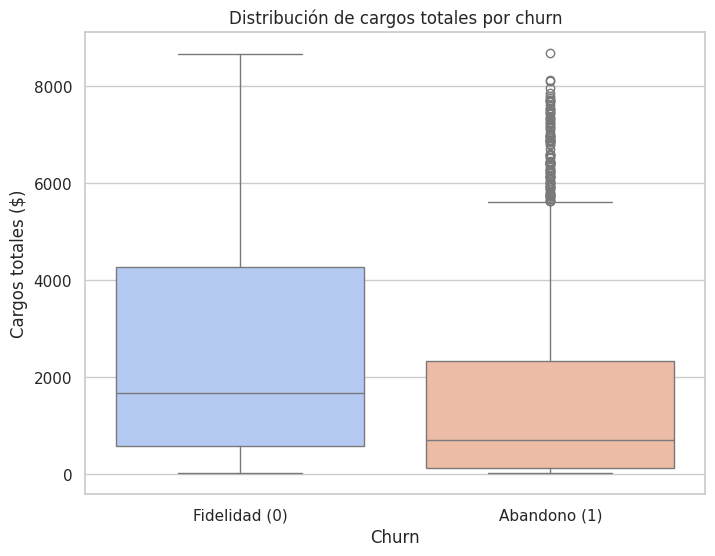

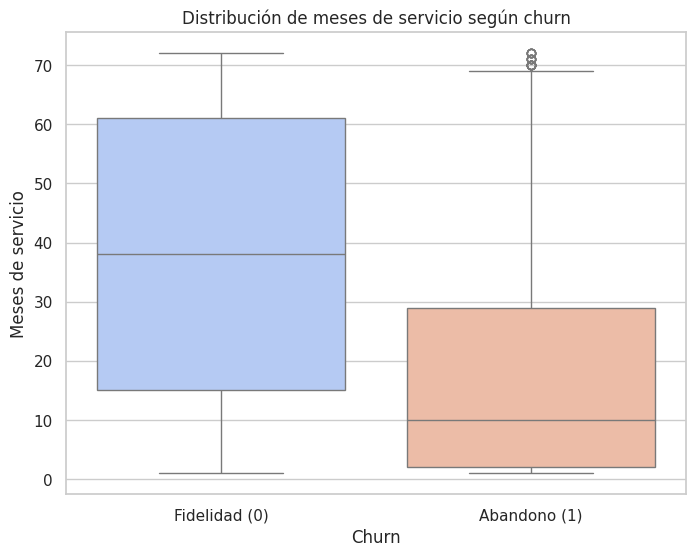

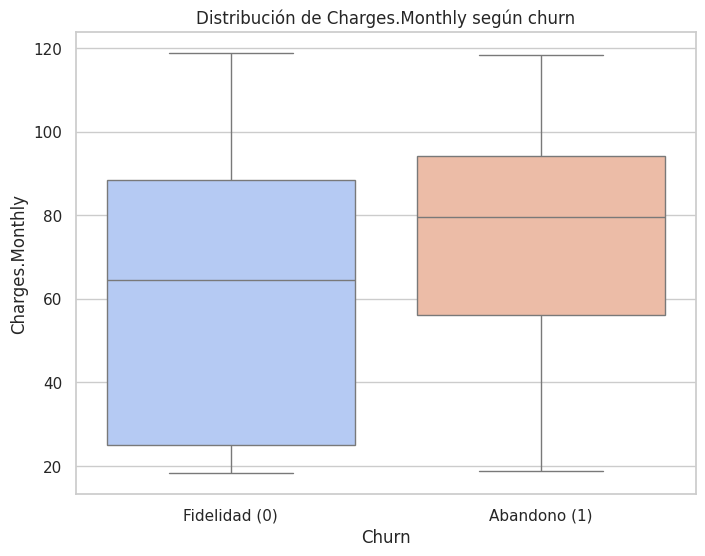

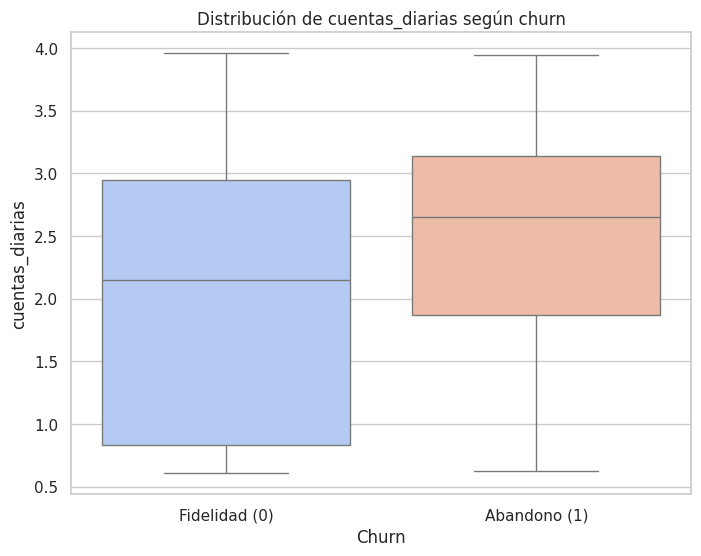

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot de cargos totales según churn
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Churn', y='Charges.Total', hue='Churn', palette='coolwarm' , legend=False)
plt.title('Distribución de cargos totales por churn')
plt.xticks([0,1], ['Fidelidad (0)', 'Abandono (1)'])
plt.ylabel('Cargos totales ($)')
plt.show()

# Boxplot de meses de servicio según churn
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn', palette = 'coolwarm' , legend=False)
plt.title('Distribución de meses de servicio según churn')
plt.xticks([0,1], ['Fidelidad (0)', 'Abandono (1)'])
plt.ylabel('Meses de servicio')
plt.show()

# Boxplot de meses de servicio según churn
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Churn', y='Charges.Monthly', hue='Churn' , palette='coolwarm' , legend=False)
plt.title('Distribución de Charges.Monthly según churn')
plt.xticks([0,1], ['Fidelidad (0)', 'Abandono (1)'])
plt.ylabel('Charges.Monthly')
plt.show()

# Boxplot de meses de servicio según churn
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Churn', y='cuentas_diarias', hue='Churn', palette='coolwarm', legend=False)
plt.title('Distribución de cuentas_diarias según churn')
plt.xticks([0,1], ['Fidelidad (0)', 'Abandono (1)'])
plt.ylabel('cuentas_diarias')
plt.show()

Cargos Totales por Churn:
* Clientes que abandonan tienen cargos más bajos Esto puede indicar que muchos abandonan en etapas tempranas del ciclo de vida.

*   Se observan varios valores atípicos altos en el grupo de abandono.
Esto significa que aunque la mayoría se va con bajo gasto acumulado, existen algunos clientes con alto gasto que también cancelan.


Meses de servicio por Churn


*   El abandono ocurre principalmente al inicio
El 50% de los clientes que abandonan lo hacen antes de los 10 meses, indicando una etapa crítica temprana.

*   Los primeros meses son decisivos. Implementar estrategias de retención tempranas (onboarding, incentivos en los primeros 12 meses) podría reducir significativamente el churn

Cargo mensual por Churn:
Los cargos mensuales altos están fuertemente asociados al abandono. Se recomienda:


*    Monitorear clientes con cargos superiores a $70/mes como segmento de alto riesgo

*    Ofrecer descuentos o planes alternativos a clientes con facturación elevada


*   Diseñar estrategias de retención diferenciadas según el nivel de gasto mensual












# 📄 Informe final

la fuga de clientes de la empresa no es generalizada, sino que está altamente concentrada en su segmento potencialmente más rentable. El diagnóstico central es un "Abandono Temprano en Clientes de Alto Valor".

El producto básico (plan de ~$20) funciona a la perfección y genera gran lealtad. El problema radica en que la plataforma no está logrando sostener a los usuarios que más pagan y más la usan.

La "Zona de Peligro" (Meses 2 a 4): Los clientes no huyen en su primer mes, ni se van después de un año. El abandono ocurre sistemáticamente cuando cruzan la barrera de los 2.5 meses, antes de acumular $500 en cargos.

# Plan de Acción Estratégico


Dado que sabemos que si el cliente sobrevive los primeros 6 meses se volverá leal a largo plazo, todos los esfuerzos deben centrarse en acompañar a los usuarios de alto perfil durante esta ventana crítica.

1.Intervención Temprana (Meses 1 a 3)
Dado que el abandono está perfectamente cronometrado, no podemos ser reactivos.

Acción: Rediseñar la experiencia de bienvenida exclusiva para los planes de $70.

2. Reestructuración de Precios y Auditoría de Valor
Casi la mitad de los usuarios de 70-110 están cancelando porque la diferencia de precio frente al plan básico no se justifica en su experiencia inicial.

Acción: Ofrecer un precio escalonado de entrada (ej. pagar 50 los primeros 3 meses y luego subir a 90) para que pasen la "zona de peligro" sin sentir un castigo económico mientras se enganchan al producto.

3. Entrevistas de Salida
Acaban de perder a usuarios que usaban mucho el producto y pagaban los planes más caros. Necesitamos saber exactamente con qué barrera chocaron.

Acción: Contactar personalmente a una muestra de los últimos clientes que cancelaron